# Tumour outgrowth by antigen-presentation class and lineage

Item 1 of `figures/todo_figures.md`: which classes of tumour cells grow out under
each condition and tissue setting.

One dot per simulation run, coloured by simulation type. Columns are the
antigen-presentation classes; rows separate epithelial from mesenchymal tumour
cells, which behave differently enough that pooling them would hide the thing
the figure is asked to show. The first three columns share axis limits across
both rows, so any dot's height means the same thing everywhere. The fourth
column relates class I outgrowth to class I + II outgrowth within the same run.

Reads the linked archive under `derived/`, so nothing here re-reads raw
PhysiCell output.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, "..")          # pdacagviz lives at the repo root

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import pdacagviz as viz

viz.configure(mode="article")
DERIVED = Path("../derived")
FIGURES = Path("../figures")

## Cell-type groups

Tumour cells carry both their lineage and their antigen-presentation status in
`cell_type`, so the eight combinations below are read straight off that column.

`PDAC_unclassified` is tumour with neither lineage nor class assigned, and
`epithelial_tumor` / `mesenchymal_tumor` are lineage without a class. None of
the three is one of the groups being compared, so they are excluded here rather
than folded into a class they were never assigned.

In [2]:
LINEAGES = ["epithelial", "mesenchymal"]
CLASSES = ["class1", "class2", "class1_class2"]

LABEL = {"class1": "class I", "class2": "class II", "class1_class2": "class I + II"}

def cell_type_of(lineage, klass):
    return f"{lineage}_tumor_{klass}"

GROUPS = {(l, k): cell_type_of(l, k) for l in LINEAGES for k in CLASSES}

SIM_TYPES = ["htan_wellmixed", "htan_geometries", "imc_wellmixed", "imc_spatial"]
META = ["sim_type", "sample_id", "patient_id", "geometry"]

# The named palettes colour cell types, not simulation sets, and lookup is
# strict -- an unknown key raises rather than drawing grey. So give sim_type its
# own colours from the default categorical ramp.
SIM_COLORS = dict(zip(SIM_TYPES, viz.categorical(len(SIM_TYPES))))

In [3]:
def counts(sim_type, timepoint):
    """Per-simulation counts of each lineage/class group at one timepoint."""
    path = DERIVED / f"{sim_type}-all_{timepoint}.h5ad"
    adata = ad.read_h5ad(path, backed="r")
    obs = adata.obs[["sim_id", "cell_type"] + META].copy()
    adata.file.close()

    per_type = (obs.groupby(["sim_id", "cell_type"], observed=True)
                   .size().unstack(fill_value=0))
    out = pd.DataFrame(index=per_type.index)
    for (lineage, klass), name in GROUPS.items():
        out[f"{lineage}_{klass}"] = (per_type[name] if name in per_type.columns
                                     else 0)
    meta = obs.groupby("sim_id", observed=True)[META].first()
    return out.join(meta)


frames = []
for sim_type in SIM_TYPES:
    initial, final = counts(sim_type, "initial"), counts(sim_type, "final")
    frame = initial[META].copy()
    for lineage, klass in GROUPS:
        col = f"{lineage}_{klass}"
        frame[f"initial_{col}"] = initial[col]
        frame[f"final_{col}"] = final[col].reindex(initial.index).fillna(0).astype(int)
    frames.append(frame.reset_index())

runs = pd.concat(frames, ignore_index=True)
print(f"{len(runs)} simulation runs")
runs.groupby("sim_type")[[f"initial_{l}_{k}" for l in LINEAGES for k in CLASSES]].sum().T

607 simulation runs


sim_type,htan_geometries,htan_wellmixed,imc_spatial,imc_wellmixed
initial_epithelial_class1,10668,1778,13524,13524
initial_epithelial_class2,5472,912,0,0
initial_epithelial_class1_class2,20538,3423,3495,3495
initial_mesenchymal_class1,7020,1170,9930,9930
initial_mesenchymal_class2,1458,243,0,0
initial_mesenchymal_class1_class2,9216,1536,1029,1029


## Percentage change

`(final - initial) / initial * 100`.

Where a group is absent at t=0 the change is undefined rather than zero or
infinite, so those runs are left as `NaN` and drop out of that panel. They are
counted below rather than silently discarded: for class II this removes a large
share of the runs, and that is part of the result rather than a nuisance.

In [4]:
for lineage, klass in GROUPS:
    col = f"{lineage}_{klass}"
    initial, final = runs[f"initial_{col}"], runs[f"final_{col}"]
    runs[f"change_{col}"] = np.where(
        initial > 0, (final - initial) / initial.where(initial > 0) * 100, np.nan)

pd.DataFrame(
    {"plottable runs": [int((runs[f"initial_{l}_{k}"] > 0).sum()) for l in LINEAGES for k in CLASSES],
     "initial == 0":   [int((runs[f"initial_{l}_{k}"] == 0).sum()) for l in LINEAGES for k in CLASSES]},
    index=pd.MultiIndex.from_tuples([(l, LABEL[k]) for l in LINEAGES for k in CLASSES],
                                    names=["lineage", "class"]))

plottable runs  initial == 0
lineage     class                                     
epithelial  class I                  509            98
            class II                 308           299
            class I + II             516            91
mesenchymal class I                  512            95
            class II                 245           362
            class I + II             460           147

In [5]:
# Where the undefined runs sit. Class II is absent from both IMC sets entirely,
# in either lineage, so those panels show HTAN runs only -- a property of the
# initial conditions, not of the simulations.
pd.crosstab(runs["sim_type"], runs["initial_epithelial_class2"] > 0,
            rownames=["simulation type"], colnames=["has epithelial class II at t=0"])

has epithelial class II at t=0,False,True
simulation type,,
htan_geometries,174,264
htan_wellmixed,29,44
imc_spatial,48,0
imc_wellmixed,48,0


## Figure

Two rows by four columns, each panel sized so the row totals one full column
width -- `grid` sizes panels independently and multiplies, so asking for
`width="full"` four times would give a figure four columns wide.

Both axes are symlog. Percent change runs from roughly -100 % to +10^5 %,
because a run starting with three tumour cells and ending with several hundred
is a change in the tens of thousands of percent; on a linear axis everything but
a handful of outliers collapses onto zero. Symlog keeps zero and the negative
half of the axis, which a log scale cannot.

The x axis is built either way -- counts at t=0 or at the terminal timepoint --
since the spec allowed both. `figure()` takes which, so the two versions differ
by one argument rather than by a second copy of the code.

The first three columns share limits across both rows. The fourth carries its
own, with a y = x reference: points above it are runs where class I + II
outgrew class I in the same simulation.

In [6]:
plot = runs[runs["sim_type"].isin(SIM_TYPES)].copy()
# sim_type stays a plain string, deliberately. As a pandas Categorical it keeps
# all four categories inside a subset, while pdacagviz narrows the palette to the
# levels actually present -- so a class II panel, which has no IMC runs, would
# hand seaborn a two-colour palette for a column still declaring four categories
# and be refused. Colours stay stable across panels because SIM_COLORS is keyed
# by name, not by position.
plot["sim_type"] = plot["sim_type"].astype(str)

COLS = [f"{l}_{k}" for l in LINEAGES for k in CLASSES]
LINTHRESH = 100          # linear within +/-100 %, logarithmic beyond

# A run enters a panel when the group exists at t=0, which is what makes the
# percentage defined. That membership is a property of the run, not of which
# count goes on the x axis, so both versions of the figure plot the same points.
def limits(basis):
    xs = pd.concat([plot.loc[plot[f"initial_{c}"] > 0, f"{basis}_{c}"] for c in COLS])
    ys = pd.concat([plot[f"change_{c}"] for c in COLS]).dropna()
    return (0, xs.max() * 1.15), (ys.min() * 1.3, ys.max() * 1.3)

for basis in ("initial", "final"):
    (x0, x1), (y0, y1) = limits(basis)
    print(f"{basis:8s} x 0 to {x1:>8.0f} cells   y {y0:>9.0f} to {y1:>9.0f} %")

initial  x 0 to     1620 cells   y      -130 to    322920 %
final    x 0 to     9084 cells   y      -130 to    322920 %


In [7]:
AXIS_LABEL = {"initial": "tumour cells at t=0",
              "final": "tumour cells at terminal timepoint"}


def figure(basis):
    """The 2x4 panel figure, with `basis` counts on the x axis."""
    XLIM, YLIM = limits(basis)
    fig, axes = viz.grid(2, 4, panel_size=(viz.width_of("full") / 4,) * 2)

    def style(ax, linthresh_x):
        ax.set_xscale("symlog", linthresh=linthresh_x)
        ax.set_yscale("symlog", linthresh=LINTHRESH)
        ax.axhline(0, lw=0.5, color="0.7", zorder=0)
        viz.despine(ax)

    for row, lineage in enumerate(LINEAGES):
        for col, klass in enumerate(CLASSES):
            ax = axes[row, col]
            name = f"{lineage}_{klass}"
            panel = plot[plot[f"initial_{name}"] > 0]
            viz.relationship(panel, x=f"{basis}_{name}", y=f"change_{name}",
                             hue="sim_type", kind="scatter", ax=ax,
                             palette=SIM_COLORS,
                             plot_kwargs={"s": 7, "alpha": 0.7,
                                          "edgecolor": "none", "legend": False})
            style(ax, 10)
            ax.set_xlim(*XLIM)
            ax.set_ylim(*YLIM)
            ax.set_title(f"{LABEL[klass]}  (n={len(panel)})" if row == 0
                         else f"(n={len(panel)})")
            ax.set_xlabel(AXIS_LABEL[basis] if row == 1 else "")
            ax.set_ylabel(f"{lineage}\nchange (%)" if col == 0 else "")
            if col != 0:
                ax.set_yticklabels([])
            if row != 1:
                ax.set_xticklabels([])

        # Fourth column: class I against class I + II, same run, same lineage.
        # Both axes are percentages here, so it does not vary with `basis`.
        ax = axes[row, 3]
        both = plot.dropna(subset=[f"change_{lineage}_class1",
                                   f"change_{lineage}_class1_class2"])
        viz.relationship(both, x=f"change_{lineage}_class1",
                         y=f"change_{lineage}_class1_class2",
                         hue="sim_type", kind="scatter", ax=ax,
                         palette=SIM_COLORS,
                         plot_kwargs={"s": 7, "alpha": 0.7,
                                      "edgecolor": "none", "legend": False})
        lo = min(both[f"change_{lineage}_class1"].min(),
                 both[f"change_{lineage}_class1_class2"].min()) * 1.3
        hi = max(both[f"change_{lineage}_class1"].max(),
                 both[f"change_{lineage}_class1_class2"].max()) * 1.3
        ax.plot([lo, hi], [lo, hi], lw=0.5, color="0.7", zorder=0)
        style(ax, LINTHRESH)
        ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
        ax.set_title(f"I vs I + II  (n={len(both)})" if row == 0
                     else f"(n={len(both)})")
        ax.set_xlabel("class I change (%)" if row == 1 else "")
        ax.set_ylabel("class I + II change (%)")

    # One legend for the whole figure, below the panels. legend_outside() places
    # it beside a single Axes, which on a four-column row lands on the next panel.
    handles = [plt.Line2D([], [], marker="o", ls="", ms=4,
                          color=SIM_COLORS[s], label=s) for s in SIM_TYPES]
    fig.tight_layout(rect=(0, 0.07, 1, 1))
    fig.legend(handles=handles, title="simulation type", loc="lower center",
               bbox_to_anchor=(0.5, 0.0), ncol=len(SIM_TYPES), frameon=False)
    return fig

/tmp/ipykernel_1576194/649965421.py:65: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=(0, 0.07, 1, 1))


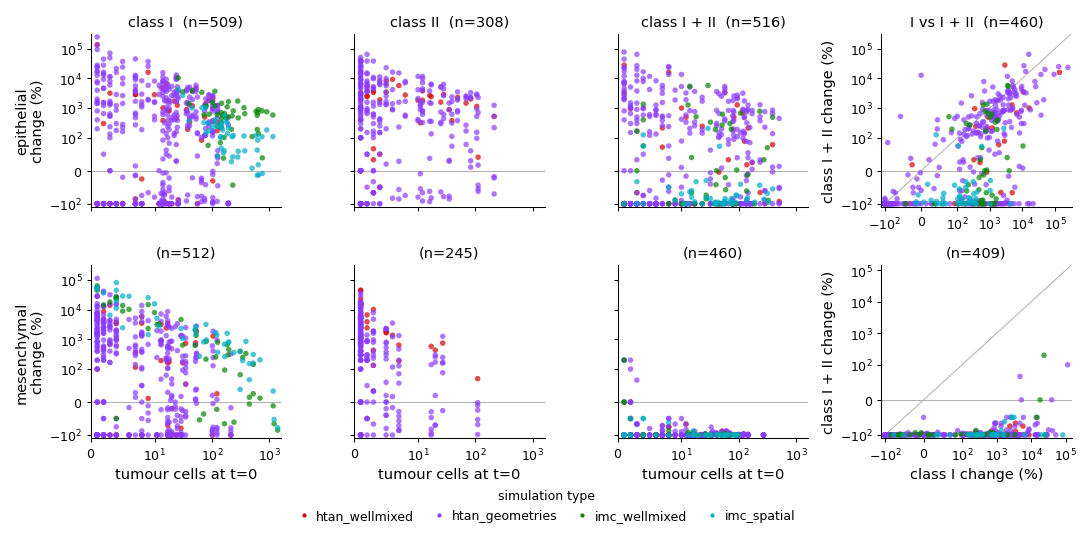

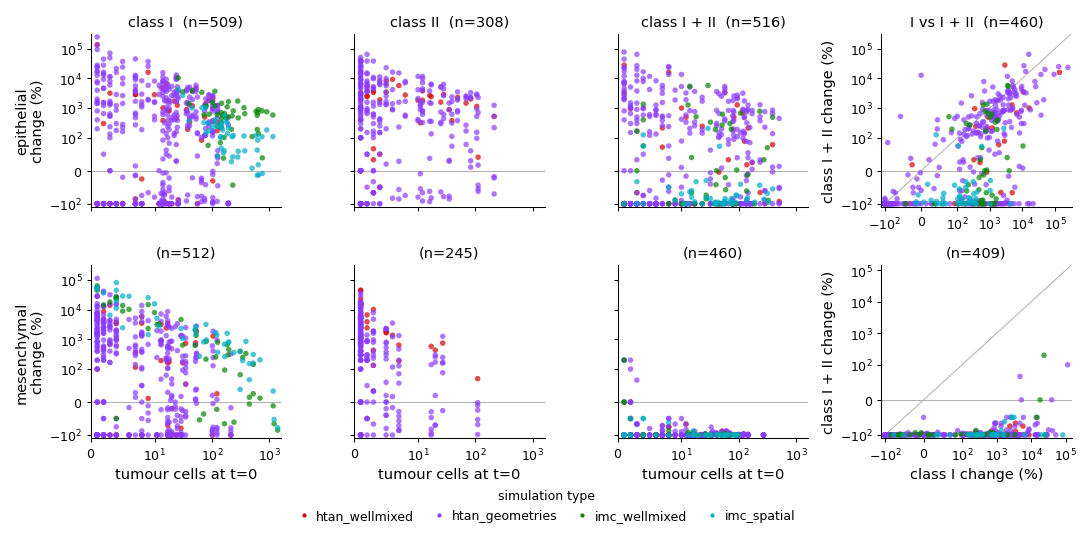

In [8]:
fig_initial = figure("initial")
viz.save(fig_initial, "tumor_outgrowth_by_class", directory=FIGURES)
fig_initial

## Alternative: terminal counts on the x axis

The same runs and the same y values, against the count each group reached rather
than the count it started from.

The two are worth reading together because each carries a different arithmetic
bias. Percent change is `(final - initial) / initial`, so plotting it against
`initial` puts the denominator on the x axis and manufactures a downward trend;
plotting it against `final` puts the numerator there and manufactures an upward
one. A pattern that survives both is about the simulations. The declining cloud
in the version above and the rising cloud below are largely the same points.

/tmp/ipykernel_1576194/649965421.py:65: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=(0, 0.07, 1, 1))


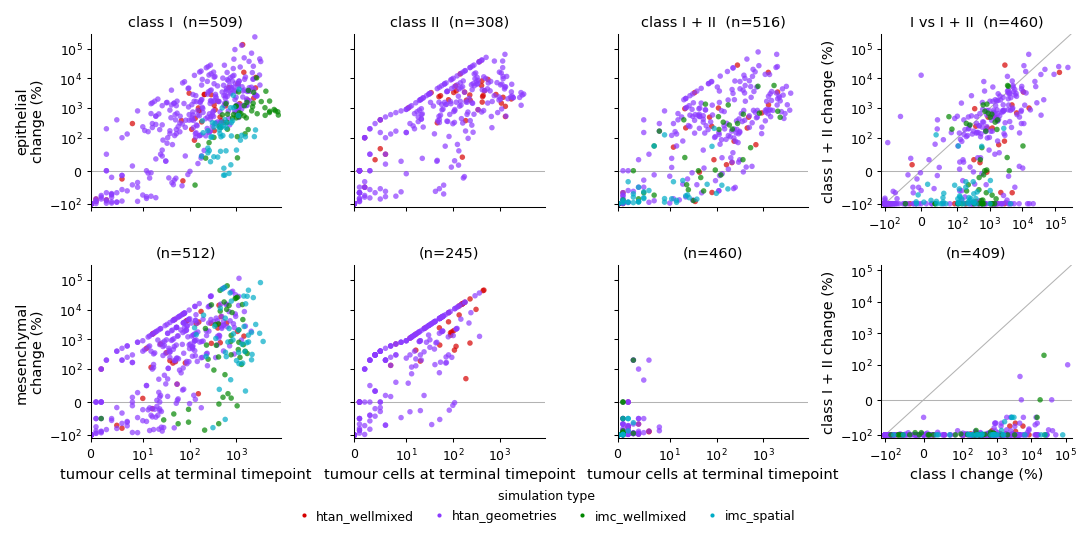

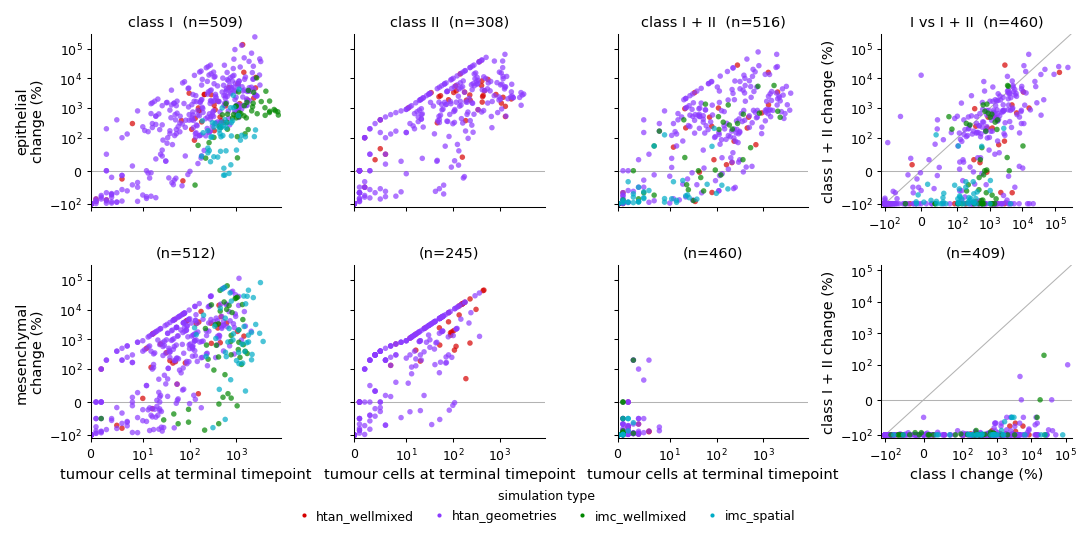

In [9]:
fig_final = figure("final")
viz.save(fig_final, "tumor_outgrowth_by_class_terminal_x", directory=FIGURES)
fig_final

## Notes

- Class II is absent from both IMC sets at t=0 in either lineage, so those
  panels carry HTAN runs only. Worth stating on the figure rather than leaving
  the reader to infer it from the point colours.
- Mesenchymal groups are smaller than epithelial throughout -- roughly a third
  the cells in the HTAN sets -- so the mesenchymal row is sparser by
  construction, not because fewer runs contributed.
- htan_geometries contributes six runs per sample, one per arrangement, so it
  dominates by count. Colour separates it, but any claim about "most runs"
  should account for that imbalance.
- The x axis uses the count at t=0, which is the denominator of the percentage,
  so the two axes are not independent: percent change compresses as the
  denominator grows. The declining trend from left to right is partly
  structural and should not be read as biology on its own.